# Revenue Visualization Analysis

## Business Context | Contexto de Negócio

### PT-BR

O objetivo desta análise é entender como a receita mensal da Olist evoluiu ao longo do tempo.

Perguntas principais:

- A receita está crescendo consistentemente?
- Existem períodos de aceleração?
- Há sinais de sazonalidade?

---

### EN

The goal of this analysis is to understand how Olist's monthly revenue evolved over time.

Main questions:

- Is revenue growing consistently?
- Are there acceleration periods?
- Are there signs of seasonality?

In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

import matplotlib.pyplot as plt
from src.revenue_analysis import analyze_monthly_revenue

monthly_revenue = analyze_monthly_revenue()

monthly_revenue.head()

Revenue base created successfully.
Rows: 99441
Columns: 11

Unique Orders:
99441

Duplicated Orders:
0


month
2017-02    291908.01
2017-03    449863.60
2017-04    417788.03
2017-05    592918.82
2017-06    511276.38
Freq: M, Name: payment_value, dtype: float64

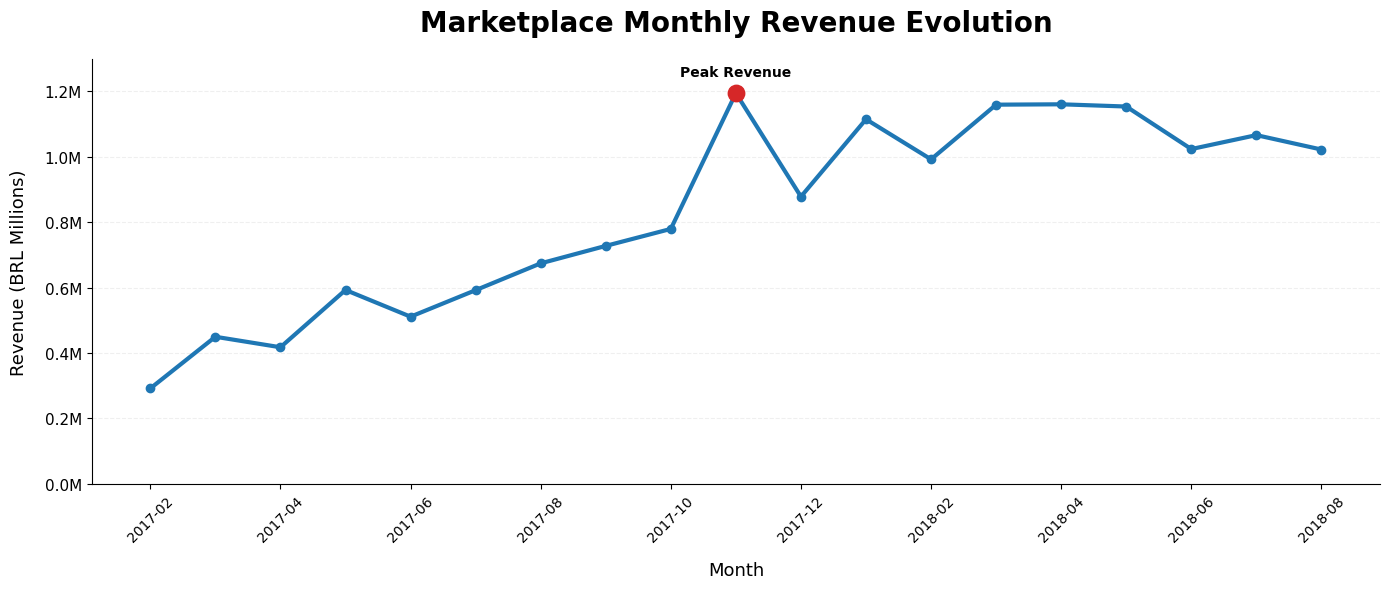

In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Plot revenue trend
ax.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    linewidth=3,
    marker='o',
    markersize=6
)

# Executive title
ax.set_title(
    "Marketplace Monthly Revenue Evolution",
    fontsize=20,
    weight="bold",
    pad=20
)

# Axis labels
ax.set_xlabel(
    "Month",
    fontsize=13,
    labelpad=12
)

ax.set_ylabel(
    "Revenue (BRL Millions)",
    fontsize=13,
    labelpad=12
)

# Convert Y-axis to millions
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x/1_000_000:.1f}M")
)

# Improve tick readability
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=11)

# Reduce X-axis clutter
ax.set_xticks(range(0, len(monthly_revenue.index), 2))
ax.set_xticklabels(
    monthly_revenue.index.astype(str)[::2],
    rotation=45
)

# Remove unnecessary borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add subtle horizontal grid
ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.2
)

# Highlight peak revenue point
peak_idx = monthly_revenue.idxmax()
peak_value = monthly_revenue.max()

ax.scatter(
    str(peak_idx),
    peak_value,
    s=140,
    color="#d62728",
    zorder=5
)

# Annotate peak point
ax.annotate(
    "Peak Revenue",
    (str(peak_idx), peak_value),
    textcoords="offset points",
    xytext=(0, 12),
    ha='center',
    fontsize=10,
    weight='bold'
)

# Improve top spacing
ax.set_ylim(0, 1_300_000)

# Optimize layout
plt.tight_layout()

# Export high-quality PNG
plt.savefig(
    "../outputs/figures/monthly_revenue_trend.png",
    dpi=300,
    bbox_inches="tight"
)

# Display chart
plt.show()

## Key Insights | Principais Insights

### PT-BR

1. A receita apresentou crescimento consistente durante 2017.
2. Novembro de 2017 apresentou o maior pico de receita.
3. Em 2018, a receita parece estabilizar acima de R$1 milhão.

---

### EN

1. Revenue showed consistent growth during 2017.
2. November 2017 presented the highest revenue peak.
3. In 2018, revenue appears to stabilize above BRL 1 million.

## Strategic Recommendation | Recomendação Estratégica

### PT-BR

Investigar campanhas comerciais ou eventos sazonais nos meses de maior crescimento.

---

### EN

Investigate commercial campaigns or seasonal events during the highest growth periods.

## Revenue Growth Analysis | Análise de Crescimento da Receita

### PT-BR

O objetivo desta análise é entender a velocidade de crescimento da receita da Olist ao longo do tempo.

Perguntas principais:

- O crescimento foi consistente?
- Houve períodos de aceleração?
- Existem meses com quedas relevantes?

---

### EN

The goal of this analysis is to understand the speed of Olist's revenue growth over time.

Main questions:

- Was growth consistent?
- Were there acceleration periods?
- Were there months with significant declines?

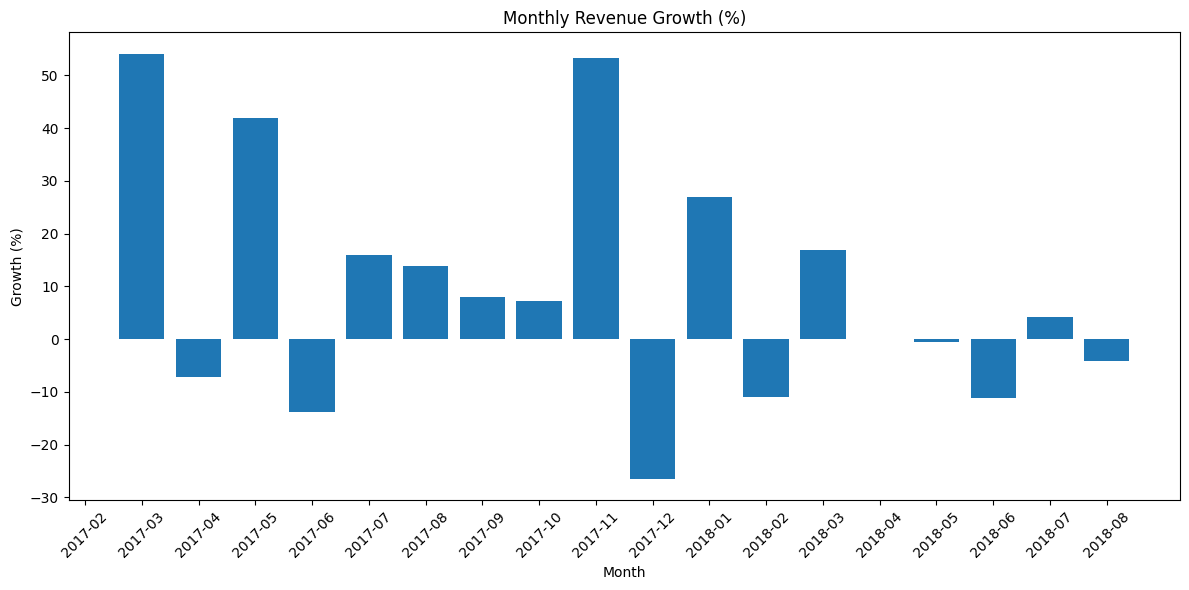

In [3]:
growth = monthly_revenue["2017-02":"2018-08"].pct_change() * 100

plt.figure(figsize=(12, 6))

plt.bar(
    growth.index.astype(str),
    growth.values
)

plt.title("Monthly Revenue Growth (%)")
plt.xlabel("Month")
plt.ylabel("Growth (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Key Insights | Principais Insights

### PT-BR

1. O crescimento mensal apresentou alta volatilidade ao longo do período.
2. Os maiores picos de crescimento ocorreram em março, maio e novembro de 2017.
3. Após meses de forte crescimento, foram observadas correções naturais.

### Interpretação de Negócio

Os dados sugerem possível influência de campanhas comerciais ou fatores sazonais em meses específicos.

---

### EN

1. Monthly growth showed high volatility throughout the analyzed period.
2. The highest growth peaks occurred in March, May, and November 2017.
3. After strong growth periods, natural corrections were observed.

### Business Interpretation

The data suggests possible influence from commercial campaigns or seasonal factors in specific months.

## Statistical Validation | Validação Estatística

### PT-BR

Após identificar visualmente oscilações no crescimento da receita, esta etapa busca validar estatisticamente se esses movimentos representam comportamentos normais ou eventos fora do padrão.

Perguntas principais:

- Qual é o crescimento médio?
- Qual é a dispersão dos dados?
- Existem meses estatisticamente anormais?

---

### EN

After visually identifying revenue growth fluctuations, this step aims to statistically validate whether these movements represent normal behavior or outlier events.

Main questions:

- What is the average growth?
- What is the data dispersion?
- Are there statistically abnormal months?

In [4]:
growth.describe()

count    18.000000
mean      9.317293
std      22.686280
min     -26.486390
25%      -6.381627
50%       5.650047
75%      16.600265
max      54.111427
Name: payment_value, dtype: float64

## Statistical Validation | Validação Estatística

### 1. Growth Distribution | Distribuição de Crescimento

#### PT-BR

Para validar a dispersão dos dados, comparamos média e mediana:

Mean (Média): 9.32%  
Median (Mediana): 5.65%

Como:

Mean > Median

Isso sugere assimetria positiva, indicando que alguns meses com crescimento extremo elevaram a média.

---

#### EN

To validate data dispersion, mean and median were compared:

Mean: 9.32%  
Median: 5.65%

Since:

Mean > Median

This suggests positive skewness, indicating that some extreme growth months increased the average.

---

### 2. Operational Volatility | Volatilidade Operacional

#### Calculation | Cálculo

Volatility Ratio:

22.69 ÷ 9.32 = 2.43x

#### PT-BR

O desvio padrão é 2.43 vezes maior que a média, indicando alta volatilidade operacional.

#### EN

Standard deviation is 2.43 times higher than average growth, indicating high operational volatility.

---

### 3. Z-Score Validation | Validação com Z-Score

Formula:

```
z = (x - μ) / σ
```

Applied:

```
z = (54.11 - 9.32) / 22.69
z = 44.79 / 22.69
z ≈ 1.97
```

#### PT-BR

Março/2017 ficou aproximadamente 1.97 desvios padrão acima da média.

#### EN

March/2017 was approximately 1.97 standard deviations above average.

In [5]:
growth_mean = growth.mean()
growth_std = growth.std()

z_scores = (growth - growth_mean) / growth_std

z_scores

month
2017-02         NaN
2017-03    1.974503
2017-04   -0.724991
2017-05    1.437048
2017-06   -1.017658
2017-07    0.288555
2017-08    0.199564
2017-09   -0.061893
2017-10   -0.096258
2017-11    1.936682
2017-12   -1.578209
2018-01    0.776606
2018-02   -0.895143
2018-03    0.331855
2018-04   -0.406394
2018-05   -0.436537
2018-06   -0.907661
2018-07   -0.227043
2018-08   -0.593028
Freq: M, Name: payment_value, dtype: float64

In [6]:
significant_months = z_scores[abs(z_scores) >= 1]

significant_months.sort_values(ascending=False)

month
2017-03    1.974503
2017-11    1.936682
2017-05    1.437048
2017-06   -1.017658
2017-12   -1.578209
Freq: M, Name: payment_value, dtype: float64

## Outlier Detection | Detecção de Outliers

### PT-BR

Para identificar comportamentos estatisticamente relevantes, foi aplicado Z-Score.

Critério utilizado:

- |z| < 1 → comportamento normal
- 1 ≤ |z| < 2 → comportamento incomum
- |z| ≥ 2 → potencial outlier

#### Meses identificados:

- Março/2017 → z = +1.97
- Novembro/2017 → z = +1.94
- Maio/2017 → z = +1.44
- Junho/2017 → z = -1.02
- Dezembro/2017 → z = -1.58

### Principais Insights

Março e Novembro de 2017 ficaram extremamente próximos do limite clássico de outlier estatístico (2σ), sugerindo eventos comerciais fora do comportamento operacional normal.

Dezembro/2017 apresentou forte correção após o pico de novembro, sugerindo possível efeito pós-campanha.

---

### EN

To identify statistically relevant behavior, Z-Score was applied.

Threshold used:

- |z| < 1 → normal behavior
- 1 ≤ |z| < 2 → unusual behavior
- |z| ≥ 2 → potential outlier

#### Identified months:

- March/2017 → z = +1.97
- November/2017 → z = +1.94
- May/2017 → z = +1.44
- June/2017 → z = -1.02
- December/2017 → z = -1.58

### Key Insights

March and November 2017 were extremely close to the classic statistical outlier threshold (2σ), suggesting commercial events outside normal operational behavior.

December/2017 showed a strong correction after November's peak, suggesting a possible post-campaign effect.

## Top Revenue Months Analysis | Análise dos Melhores Meses de Receita

### PT-BR

Após analisar a evolução temporal e a taxa de crescimento da receita, esta etapa busca identificar quais meses entregaram os maiores volumes absolutos de faturamento.

Perguntas principais:

- Quais meses geraram mais receita?
- Existe concentração em períodos específicos?
- Há sinais de sazonalidade comercial?

---

### EN

After analyzing revenue trends and growth rates, this step aims to identify which months generated the highest absolute revenue.

Main questions:

- Which months generated the highest revenue?
- Is there concentration in specific periods?
- Are there signs of commercial seasonality?

In [7]:
top_revenue_months = (
    monthly_revenue
    .sort_values(ascending=False)
    .head(5)
)

top_revenue_months

month
2017-11    1194882.80
2018-04    1160785.48
2018-03    1159652.12
2018-05    1153982.15
2018-01    1115004.18
Freq: M, Name: payment_value, dtype: float64

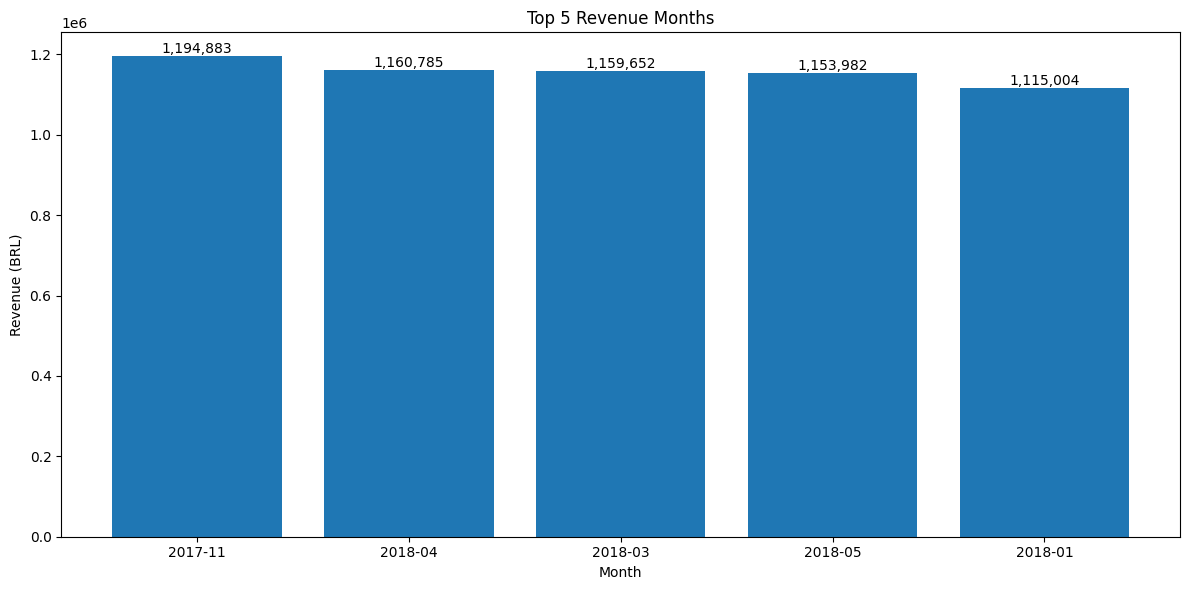

In [8]:
plt.figure(figsize=(12, 6))

bars = plt.bar(
    top_revenue_months.index.astype(str),
    top_revenue_months.values
)

plt.title("Top 5 Revenue Months")
plt.xlabel("Month")
plt.ylabel("Revenue (BRL)")

for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

---

#### EN

Among the top 5 revenue months:

- 4 out of 5 months (80%) occurred in 2018.


This suggests that the business reached higher commercial maturity in 2018.

---

### Insight 2 — Peak Performance | Pico de Performance

#### PT-BR

Novembro/2017 apresentou o maior faturamento:

R$ 1,194,882.80

Comparando com o quinto melhor mês:

R$ 1,115,004.18

Calculation:

79,878.62 ÷ 1,115,004.18 = 7.16%

Novembro superou o quinto melhor mês em aproximadamente 7.16%, indicando performance acima do padrão.

---

#### EN

November/2017 presented the highest revenue:

BRL 1,194,882.80

Compared with the fifth-best month:

BRL 1,115,004.18

Calculation:

79,878.62 ÷ 1,115,004.18 = 7.16%

November outperformed the fifth-best month by approximately 7.16%, indicating above-normal performance.

---

### Insight 3 — Operational Stability | Estabilidade Operacional

#### PT-BR

Entre os melhores meses de 2018:

Highest Revenue:

R$ 1,160,785.48

Lowest Revenue:

R$ 1,115,004.18

Calculation:

45,781.30 ÷ 1,115,004.18 = 4.11%

A variação de apenas 4.11% sugere alta consistência operacional.

---

#### EN

Among the best months of 2018:

Highest Revenue:

BRL 1,160,785.48

Lowest Revenue:

BRL 1,115,004.18

Calculation:

45,781.30 ÷ 1,115,004.18 = 4.11%

A variation of only 4.11% suggests high operational consistency.

---

## Business Interpretation | Interpretação de Negócio

### PT-BR

Os dados sugerem uma possível transição entre:

- 2017 → fase de expansão comercial
- 2018 → fase de estabilização operacional

Essa hipótese é sustentada por:

- 80% dos top months em 2018
- baixa dispersão entre os melhores resultados

---

### EN

The data suggests a possible transition between:

- 2017 → commercial expansion phase
- 2018 → operational stabilization phase

This hypothesis is supported by:

- 80% of top months occurring in 2018
- low dispersion among the best results

---

## Strategic Recommendation | Recomendação Estratégica

### PT-BR

Recomenda-se investigar:

1. Campanhas comerciais entre Jan–May/2018
2. Canais de aquisição desse período
3. Performance dos sellers nesses meses

Próximas análises recomendadas:

- Cohort Analysis
- Seller Segmentation
- Category Performance

---

### EN

Recommended investigations:

1. Commercial campaigns between Jan–May/2018
2. Acquisition channels used during this period
3. Seller performance during these months

Recommended next analyses:

- Cohort Analysis
- Seller Segmentation
- Category Performance

## Executive Summary | Resumo Executivo

### 🇧🇷 Português

Durante esta análise da :contentReference[oaicite:0]{index=0}, foram identificados três padrões estratégicos de negócio:

### 1. Crescimento acelerado em 2017
A receita apresentou expansão consistente ao longo de 2017, indicando forte ganho de escala operacional e comercial.

### 2. Maturidade operacional em 2018
Dos 5 maiores meses de receita, 4 ocorreram em 2018 (80%), sugerindo que a empresa atingiu um novo patamar de estabilidade financeira e eficiência comercial.

### 3. Eventos de performance acima da média
Meses como março e novembro de 2017 apresentaram crescimento estatisticamente acima do comportamento médio, possivelmente associados à sazonalidade, campanhas promocionais ou expansão do marketplace.

### Próximos passos estratégicos

- Investigar campanhas, eventos comerciais e fatores externos associados aos meses de alta performance.
- Replicar estratégias comerciais observadas nos períodos de crescimento excepcional.
- Implementar monitoramento contínuo para antecipar padrões sazonais e prever futuras oportunidades de crescimento.


---

### 🇺🇸 English

During this analysis of :contentReference[oaicite:1]{index=1}, three major business patterns were identified:

### 1. Accelerated growth in 2017
Revenue showed consistent expansion throughout 2017, indicating strong operational and commercial scaling.

### 2. Operational maturity in 2018
4 out of the top 5 revenue months (80%) occurred in 2018, suggesting the company reached a higher level of financial stability and commercial efficiency.

### 3. Above-average performance events
Months such as March and November 2017 showed statistically significant growth compared to average behavior, potentially linked to seasonality, marketing campaigns, or marketplace expansion.

### Strategic next steps

- Investigate campaigns, commercial events, and external factors linked to peak-performance months.
- Replicate successful commercial strategies from exceptional growth periods.
- Implement continuous monitoring to identify seasonal patterns and forecast future growth opportunities.